In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv


---
# Imports 
## (and Unused Pre-process)
---

In [2]:
###
### Γεώργιος Σκούρας sdi2100172
###

# (Uncomment to install if needed)
#!pip install transformers datasets 
# !pip install optuna  
# !pip install wordcloud
# !pip install contractions
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import os
import random
import numpy as np
import pandas as pd
import torch
import time
from tqdm.auto import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns




# HuggingFace & PyTorch imports
from transformers import (
    BertTokenizer,
    BertConfig,
    BertModel,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import SequenceClassifierOutput
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    confusion_matrix
)

###
### Taken from project 1 and 2 but in the end was not used (ignore)
### 

# import re
# import html
# import unicodedata
# from nltk.tokenize import word_tokenize
# import contractions  # pip install contractions if needed

# # Abbreviation and emoticon maps
# abbreviations = {
#     "u": "you", "ur": "your", "r": "are", "pls": "please", "thx": "thanks",
#     "k": "okay", "y": "why"
# }
# emoticon_dict = {
#     ":)": "happy", ":D": "laughing", ";)": "wink",
#     ":(": "sad", ":/": "confused", ":|": "neutral",
#     ":'(": "crying", ":o": "surprised", ":O": "shocked",
# }

# def preprocess_emojis(text):
#     for emoticon, meaning in emoticon_dict.items():
#         text = re.sub(re.escape(emoticon), meaning, text)
#     return text

# def expand_abbreviations(text):
#     pattern = r'\b(' + '|'.join(abbreviations.keys()) + r')\b'
#     return re.sub(pattern, lambda m: abbreviations[m.group(0)], text)

# def convert_punctuation(text):
#     text = text.replace("!", " <EXCLAMATION> ")
#     text = text.replace("?", " <QUESTION> ")
#     text = text.replace(".", " <PERIOD> ")
#     text = text.replace('"', " <QUOTE> ")
#     return text

# def preprocess_text(text):
#     text = text.lower()
#     text = html.unescape(text)
#     text = contractions.fix(text)
#     text = expand_abbreviations(text)
#     text = preprocess_emojis(text)
#     text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '<EMAIL>', text)
#     text = convert_punctuation(text)
#     text = re.sub(r'https?://\S+|www\.\S+', '<URL_LINK>', text)
#     text = re.sub(r'@\w+', '<USER>', text)
#     text = re.sub(r'(.)\1{2,}', r'\1', text)
#     text = re.sub(r'\d+', '<NUM>', text)
#     text = unicodedata.normalize('NFKD', text).encode('ascii','ignore').decode('utf-8','ignore')
   
#     text = re.sub(r'\s+', ' ', text).strip()
#     tokens = word_tokenize(text)
#     # join back into a single string for the HuggingFace tokenizer
#     return " ".join(tokens)


###
### Taken from project 1 and 2
### 



# Model checkpoint
MODEL_NAME = "bert-base-uncased"

#Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Device setup
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

# Load tokenizer, config & model
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
# config    = BertConfig.from_pretrained(MODEL_NAME, num_labels=2)
# model     = BertForSequenceClassification.from_pretrained(
#                 MODEL_NAME,
#                 config=config                                                               #Used costume classifier in the end 
#             ).to(device)# Cell 1: Environment setup & imports for BERT fine-tuning


###
### Γεώργιος Σκούρας sdi2100172
###

2025-06-08 14:45:54.547025: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749393954.741598      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749393954.797023      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

---
# Basic EDA
----

In [3]:
###
### Taken from project 1 and 2 with adjustments 
###

def generate_wordcloud(text_series, max_words=200, figsize=(12,6)):
    
    # Join into one big string
    all_text = " ".join(text_series.tolist())
    wc = WordCloud(width=800, height=400, background_color="white",
                   max_words=max_words).generate(all_text)
    plt.figure(figsize=figsize)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Preprocessed Text")
    plt.show()

def plot_token_frequency(text_series, top_n=20, figsize=(12,6)):
    
    # Split into tokens
    tokens = " ".join(text_series.tolist()).split()
    freq   = Counter(tokens)
    common = freq.most_common(top_n)
    words, counts = zip(*common)
    
    plt.figure(figsize=figsize)
    plt.bar(range(len(words)), counts, tick_label=words, color='skyblue')
    plt.xticks(rotation=45, ha="right")
    plt.xlabel('Tokens')
    plt.title(f"Top {top_n} Token Frequencies")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


Train samples: 148388
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0 

Train class distribution:
Label
1    74196
0    74192
Name: count, dtype: int64 



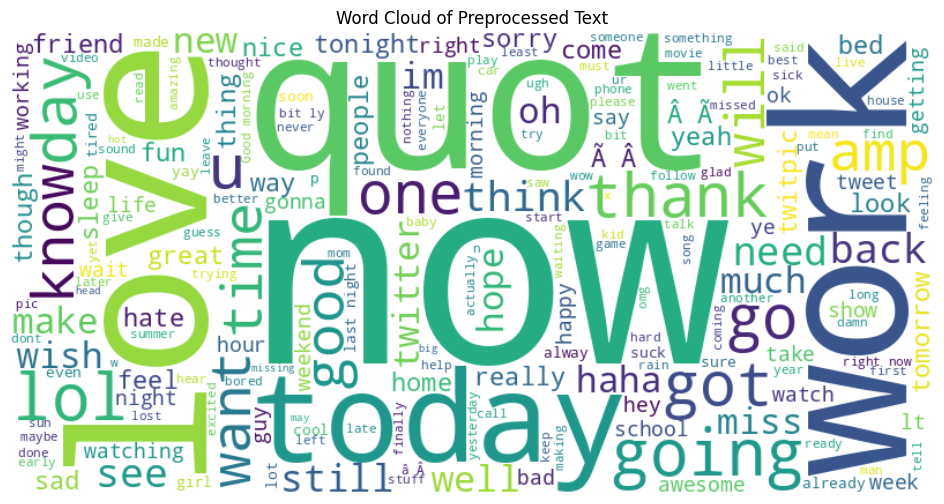

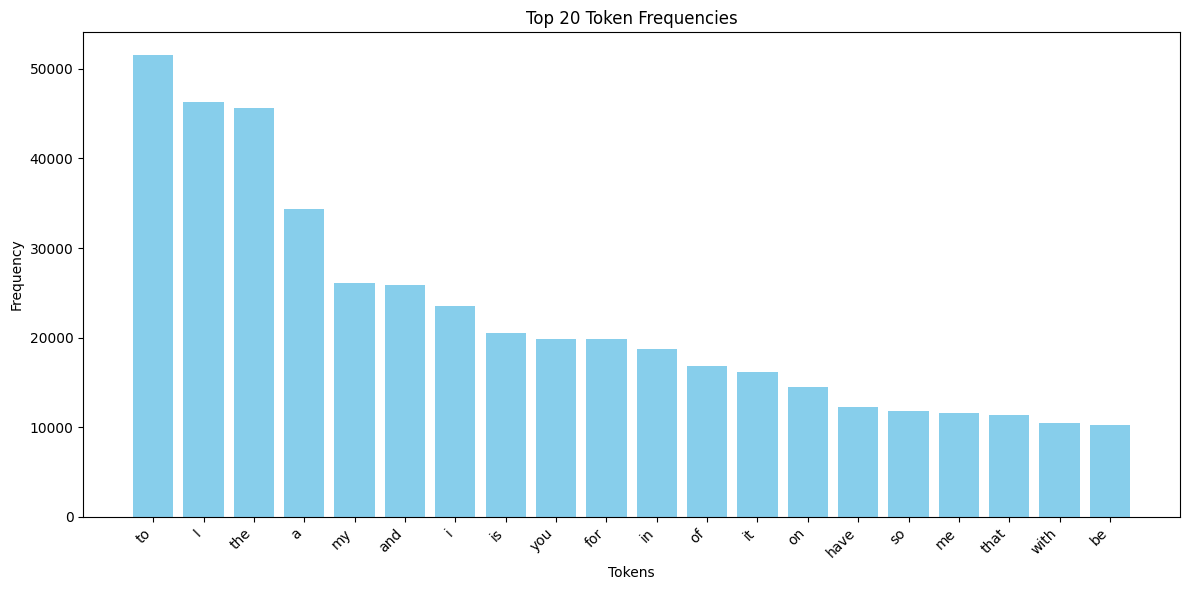

Batches — train: 2319, val: 663, test: 332, small_train: 1160


In [4]:

train_df = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv")
val_df   = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv")
test_df  = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv")

#  Inspect and preview the first few rows
print(f"Train samples: {len(train_df)}")
print(train_df.head(), "\n")
print("Train class distribution:")
print(train_df['Label'].value_counts(), "\n")

### Not used (was for my pre-process)
# # 1) Apply preprocessing to the raw Text column
# train_df['Text'] = train_df['Text'].apply(preprocess_text)
# val_df  ['Text'] = val_df  ['Text'].apply(preprocess_text)
# test_df ['Text'] = test_df ['Text'].apply(preprocess_text)

#  EDA visualizations here
generate_wordcloud(train_df['Text']) # Visual summary of most common words
plot_token_frequency(train_df['Text'])  # Bar chart of top tokens by frequency

# PyTorch-compatible dataset for sentiment classification using Bert
class BERTDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128, is_test=False):
        self.texts = df['Text'].tolist()
        #self.texts = df['Text'].apply(preprocess_text).tolist()
        self.labels = df['Label'].tolist() if not is_test else None
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test

    def __len__(self):
        return len(self.texts)
        
    # Get the raw text at the given index
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus( # Tokenize the input text
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        # Format as a dictionary with necessary inputs
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }
        # But add label only if it's not a test sample
        if not self.is_test:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
        
# Instantiate datasets & dataloaders
BATCH_SIZE = 64
# Create dataset objects for training, validation, and test
train_dataset = BERTDataset(train_df, tokenizer)
val_dataset   = BERTDataset(val_df, tokenizer)
test_dataset  = BERTDataset(test_df, tokenizer, is_test=True)

# Create data loaders to efficiently feed data into the model
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# Used for optuna (so not used for the actual program)
small_train_loader = DataLoader(
    torch.utils.data.Subset(train_dataset, list(range(len(train_dataset)//2))),
    batch_size=BATCH_SIZE, shuffle=True
)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}, small_train: {len(small_train_loader)}")

---
# Bert Classifier
---

In [5]:
class BertClassifier(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased", # Pretrained BERT model name
        hidden_dim=512, # Hidden dimension for the classifier head
        num_labels=2,   # We're doing binary classification 
        dropout_prob=0.2   # Dropout probability for regularization
    ):
        super().__init__()
        # Base BERT
        self.bert = BertModel.from_pretrained(bert_model_name)
        # Classification head (implementing dropout and RElu)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(self.bert.config.hidden_size, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, num_labels)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        #  Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Extract the CLS embedding
        cls_rep = outputs.last_hidden_state[:, 0, :]
        # Pass through our classifier head to get the final logits (raw predictions)
        logits = self.classifier(cls_rep)

        # If we have labels, calculate the classification loss (used during training)
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        # Return loss (if any) and logits
        return SequenceClassifierOutput(loss=loss, logits=logits)

# Move to device
model = BertClassifier().to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

---
# Optuna
---

In [6]:
###
### Optuna (was used but it didnt really help achieving best results)
###

# import optuna
# from sklearn.metrics import accuracy_score

# # Make sure EPS is defined
# EPS = 1e-8
# FINAL_EPOCHS = 2

# def objective(trial):
#     # 1) Sample hyperparameters
#     hidden_dim   = trial.suggest_int("hidden_dim",    128, 1024, step=128)
#     dropout_prob = trial.suggest_float("dropout_prob", 0.1, 0.5, step=0.1)
#     lr           = trial.suggest_float("lr",           1e-5, 5e-5, log=True)
#     weight_decay = trial.suggest_float("weight_decay", 0.0, 0.1)

#     # 2) Build model & optimizer/scheduler for *this* trial
#     model = BertClassifier(
#         bert_model_name=MODEL_NAME,
#         hidden_dim=hidden_dim,
#         dropout_prob=dropout_prob
#     ).to(device)

#     optimizer = AdamW(model.parameters(), lr=lr, eps=EPS, weight_decay=weight_decay)
#     total_steps = len(small_train_loader) * 2
#     scheduler = get_linear_schedule_with_warmup(
#         optimizer,
#         num_warmup_steps=int(0.1*total_steps),
#         num_training_steps=total_steps
#     )

#     # 3) Train for 2 quick epochs
#     train_losses, val_losses = [], []
#     for epoch in range(2):
#         model.train()
#         for batch in small_train_loader:
#             inputs = {k: v.to(device) for k, v in batch.items()}
#             outputs = model(**inputs)
#             loss = outputs.loss
#             optimizer.zero_grad()
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#             optimizer.step()
#             scheduler.step()
#             train_losses.append(loss.item())

#         # validation pass
#         model.eval()
#         all_preds, all_labels = [], []
#         with torch.no_grad():
#             for batch in val_loader:
#                 inputs = {k: v.to(device) for k, v in batch.items() if k!="labels"}
#                 logits = model(**inputs).logits
#                 all_preds.extend(logits.argmax(dim=1).cpu().numpy())
#                 all_labels.extend(batch["labels"].numpy())
#         val_acc = accuracy_score(all_labels, all_preds)

#         # pruning support
#         trial.report(val_acc, epoch)
#         if trial.should_prune():
#             raise optuna.TrialPruned()

#     # 4) Compute average losses
#     avg_train_loss = sum(train_losses) / len(train_losses)
#     # we only tracked val_acc, so we'll just report that metric
#     avg_val_loss = None  # if you also tracked losses in validation, compute here

#     # 5) Print a summary for this trial
#     print(f">> Trial {trial.number:>2}: "
#           f"hidden_dim={hidden_dim}, dropout={dropout_prob:.1f}, "
#           f"lr={lr:.1e}, wd={weight_decay:.2f}  "
#           f"| train_loss={avg_train_loss:.4f}, val_acc={val_acc:.4f}")

#     # 6) You can also store these as user attributes if you want:
#     trial.set_user_attr("train_loss", avg_train_loss)
#     trial.set_user_attr("val_acc", val_acc)

#     return val_acc

# # 7) Run the study
# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(),
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
# )
# timeout = 10 * 60 * 60 #10h
# study.optimize(objective, n_trials=16, timeout=timeout)

# # 8) After it finishes, you can dump the trial-by-trial results:
# df = study.trials_dataframe()
# print(df.columns) 

# print(df)
# print("\nBest validation accuracy:", study.best_value)
# print("Best hyperparameters:", study.best_params)
# df.to_csv("optuna_trials.csv", index=False)
# print("✅ Saved optuna_trials.csv")
# best = study.best_params
# model = BertClassifier(
#     bert_model_name=MODEL_NAME,
#     hidden_dim   = best["hidden_dim"],
#     dropout_prob = best["dropout_prob"]
# ).to(device)

# optimizer = AdamW(model.parameters(), lr=best["lr"], eps=EPS, weight_decay=best["weight_decay"])
# total_steps = len(small_train_loader) * FINAL_EPOCHS
# scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)

###
### Optuna
###

In [7]:
###
### Taken from project 1 and 2 with adjustments 
###

# ---- Plotting Functions ----

def plot_roc_curve(model, dataloader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]

            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            preds = (probs >= 0.5).int()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1, linecolor='black')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

def plot_learning_curve(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

---
# Training Model
---


===== Epoch 1/3 =====


Training:   0%|          | 0/2319 [00:00<?, ?it/s]

 Train Loss: 0.3999 | Acc: 0.8159 | Prec: 0.8099 | Rec: 0.8256 | F1: 0.8177


Validating:   0%|          | 0/663 [00:00<?, ?it/s]

 Val   Loss: 0.3471 | Acc: 0.8505 | Prec: 0.8495 | Rec: 0.8519 | F1: 0.8507
✅ Best model saved.

===== Epoch 2/3 =====


...

 Val   Loss: 0.3534 | Acc: 0.8552 | Prec: 0.8626 | Rec: 0.8449 | F1: 0.8536
✅ Best model saved.

===== Epoch 3/3 =====


Training:   0%|          | 0/2319 [00:00<?, ?it/s]

 Train Loss: 0.1882 | Acc: 0.9281 | Prec: 0.9313 | Rec: 0.9245 | F1: 0.9279


Validating:   0%|          | 0/663 [00:00<?, ?it/s]

 Val   Loss: 0.4029 | Acc: 0.8523 | Prec: 0.8557 | Rec: 0.8474 | F1: 0.8515

 Best Validation Accuracy: 0.8552


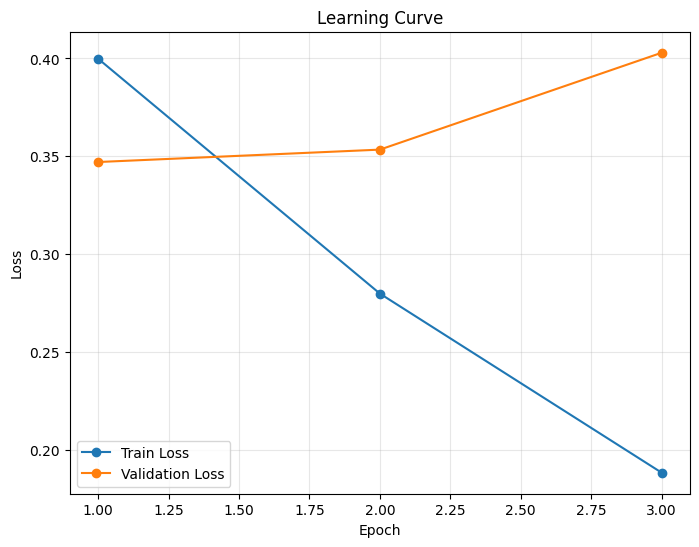

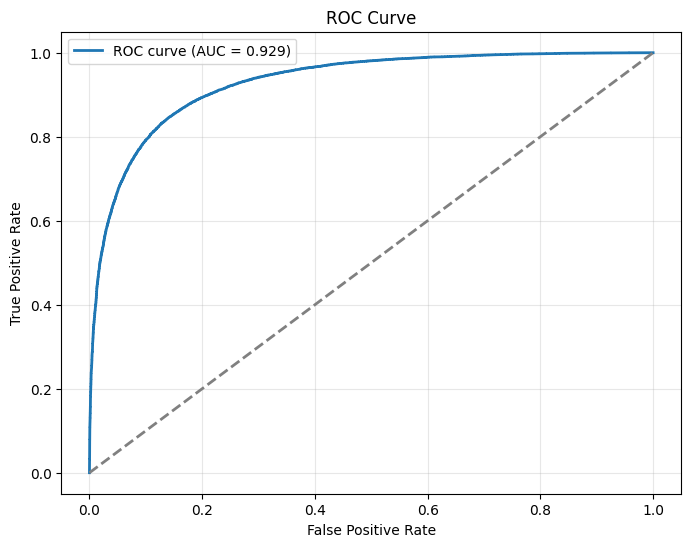

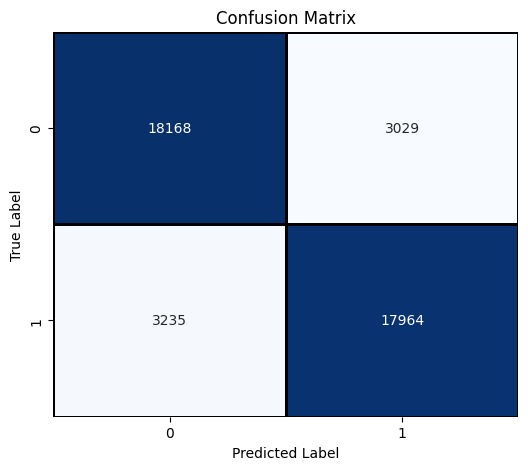

In [8]:
# Parameters
EPOCHS = 3 # Number of passes through the training data
LEARNING_RATE = 3e-5 # How big each update step is (too big = unstable, too small = slow)
EPS = 1e-8 # Small value to prevent division by 0 in Adam optimizer
WEIGHT_DECAY=0.01 # Regularization to prevent overfitting

# Optimizer & scheduler

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=EPS,weight_decay=WEIGHT_DECAY)
# Total number of batches across all epochs
total_steps = len(train_loader) * EPOCHS
# Scheduler gradually increases then decreases the learning rate
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps), # 10% steps
    num_training_steps=total_steps
)
# Track losses for plotting later
train_losses_all = []
val_losses_all = []
#Training function
def train_model(model,train_loader,val_loader,optimizer,scheduler,epochs,save_path="best_bert_model.pt"):
    best_val_acc = 0.0  # Track best validation accuracy so we can save the best mode

    for epoch in range(1, epochs + 1):
        print(f"\n===== Epoch {epoch}/{epochs} =====")
        
        # ---- Training ----
        model.train() # Set to training mode
        train_losses = []
        train_preds, train_labels = [], []
        
        for batch in tqdm(train_loader, desc="Training", leave=False):
            inputs = { # A check
                "input_ids":      batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "labels":         batch["labels"].to(device)
            }

            outputs = model(**inputs)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            # Track loss and predictions for training metrics
            train_losses.append(loss.item())
            preds = logits.argmax(dim=1).cpu().numpy()
            labels = inputs["labels"].cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels)

        # Compute training metrics
        train_acc  = accuracy_score(train_labels, train_preds)
        train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(train_labels, train_preds, average='binary')
        avg_train_loss = np.mean(train_losses)
        train_losses_all.append(avg_train_loss)

        print(f" Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")

        
        # ---- Validation ----
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validating", leave=False):
                inputs = {
                    "input_ids":      batch["input_ids"].to(device),
                    "attention_mask": batch["attention_mask"].to(device),
                    "labels":         batch["labels"].to(device)
                }

                outputs = model(**inputs)
                val_losses.append(outputs.loss.item())

                preds = outputs.logits.argmax(dim=1).cpu().numpy()
                labels = inputs["labels"].cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels)
                
        # Compute validation metrics
        val_acc  = accuracy_score(val_labels, val_preds)
        val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='binary')
        avg_val_loss = np.mean(val_losses)
        val_losses_all.append(avg_val_loss)

        print(f" Val   Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")

        # Save the model if this is the best so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Best model saved.")

    print(f"\n Best Validation Accuracy: {best_val_acc:.4f}")




# Run it
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=3,              # or however many
    save_path="best_bert_model.pt"
)

 # ---- Post‐training plots ----
plot_learning_curve(train_losses_all, val_losses_all)
plot_roc_curve(model, val_loader)
plot_confusion_matrix(model, val_loader)

---
# Submission 
---

In [9]:

# Reload best weights
model.load_state_dict(torch.load("best_bert_model.pt"))
model.to(device)
model.eval()

# Make predictions on the test set (no labels)
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1).cpu().numpy()

        test_preds.extend(preds)

# Build & save submission
submission = pd.DataFrame({
    "ID": test_df["ID"],         
    "Label": test_preds          #
})

# Preview
print(submission.head())
submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved as submission.csv")

/tmp/ipykernel_19/4020644744.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_bert_model.pt"))


       ID  Label
0  102388      1
1  153802      0
2   61831      0
3   18317      1
4   50061      1
✅ Submission file saved as submission.csv
